# **Dynamic Time Warping (DTW) for Audio-Video Matching: A Failed Attempt**

## **1. Introduction**
Initially, we attempted to match audio and video using **Dynamic Time Warping (DTW)**.  
This approach involved extracting **peaks and valleys** from video frames and **spikes** from the audio signal. The idea was to match these patterns using DTW to find an alignment between audio and video.

---

## **2. DTW-Based Matching Approach**

### **Step 1: Extracting Peaks & Valleys from Video Frames**
- Processed each video to identify **key points** (peaks and valleys) in frame intensity changes.
- These features represent important motion transitions in the video.

### **Step 2: Extracting Spikes from Audio**
- Extracted **loudness spikes** from audio signals to find key moments.
- Used **short-term energy** and **spectral flux** to identify prominent peaks.

### **Step 3: Applying DTW for Sequence Matching**
- Used **Dynamic Time Warping (DTW)** to align the extracted peaks (video) with spikes (audio).
- The goal was to **minimize the alignment cost** and find the best possible mapping.

---

## **3. Why DTW Failed?**
🚫 **Mismatch of Features:**  
- The extracted peaks/valleys from video were **not consistently aligned** with audio spikes.  
- Many visual peaks were due to **illumination changes**, not real scene transitions.

🚫 **Temporal Misalignment Issues:**  
- Audio and video had **different time scales**, leading to incorrect DTW mappings.  
- DTW forces alignment, even if the match is **not meaningful**.

🚫 **High Computational Cost:**  
- DTW is **computationally expensive** for long sequences.  
- Processing large datasets was inefficient.

---

## **4. Shift to a Better Approach: Hungarian Algorithm**

Since DTW-based matching failed, we switched to a **Hungarian Algorithm-based approach**:  
✅ Used **binary feature vectors** from audio and video instead of peaks/spikes.  
✅ Applied **Jaccard similarity** for comparing features.  
✅ Used the **Hungarian Algorithm** to ensure a strict **one-to-one matching** between video and audio.  

This approach provided **better accuracy, faster computation, and unique pairings.** 🎯

---

## **5. Conclusion**
While DTW is useful in some scenarios, it was **not suitable** for our audio-video matching task due to inconsistencies in extracted features and high computational cost. The **Hungarian Algorithm** provided a more robust solution with precise one-to-one assignments.

🚀 **This switch significantly improved the accuracy and efficiency of our matching process!**


In [78]:
# Importing Libraries:
import os
import cv2
import numpy as np
import librosa
import librosa.display
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cosine, euclidean
from fastdtw import fastdtw
from scipy.signal import find_peaks, peak_widths
import ffmpeg
import matplotlib.pyplot as plt

In [40]:
def extract_video_features(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    # Parameters for Ball Detection:
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea = True
    params.minArea = 20
    params.maxArea = 500
    params.filterByCircularity = True
    params.minCircularity = 0.8
    detector = cv2.SimpleBlobDetector_create(params)

    # Data:
    time = []
    x_pos = []
    y_pos = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        keypoints = detector.detect(gray)
        if len(keypoints) > 0:
            for keypoint in keypoints:
                x_pos.append(int(keypoint.pt[0]))
                y_pos.append(int(keypoint.pt[1]))
                time.append(cap.get(cv2.CAP_PROP_POS_FRAMES) / fps)
        
    cap.release()
    cv2.destroyAllWindows()

    # Computing the boundaries to get the information:
    left_bound = min(x_pos)
    right_bound = max(x_pos)
    top_bound = min(y_pos)
    bottom_bound = max(y_pos)

    # Detecting collisions now:
    threshold = 2
    col_timestamps = []
    for t, x, y in zip(time, x_pos, y_pos):
        if abs(x - left_bound) < threshold:
            col_timestamps.append(("Left", t))
        if abs(x - right_bound) < threshold:
            col_timestamps.append(("Right", t))
        if abs(y - top_bound) < threshold:
            col_timestamps.append(("Top", t))
        if abs(y - bottom_bound) < threshold:
            col_timestamps.append(("Bottom", t))
    
    # Now getting a binary uniform vector which will tell whether collision occured or not:
    total_time = time[-1]
    sample_rate = 100
    uniform_vector = np.linspace(0, total_time, int(total_time * sample_rate))

    # Ensuring same length of uniform vector and tracked x & y:
    x_pos = np.interp(uniform_vector, time, x_pos)
    y_pos = np.interp(uniform_vector, time, y_pos)

    # Now filling the uniform vector with 1s where collision occured:
    collision = (np.abs(x_pos - left_bound) < threshold) | (np.abs(x_pos - right_bound) < threshold)  | (np.abs(y_pos - bottom_bound) < threshold)
    collision = collision.astype(int)

    return collision

In [55]:
# Iterating through all the videos and extracting features and appending them in a list:
video_features = []
video_dir = r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only"

for i in range(1, 46):
    # Iterate through each video
    video_file = os.path.join(video_dir, f"video_only_ID_{i}.mp4")
    features = extract_video_features(video_file)
    video_features.append(features)

In [56]:
# Ensuring that all videos got processed and have 20 * 100 = 2000 frames:
assert len(video_features) == 45

for i in range(len(video_features)):
    if len(video_features[i]) != 2000:
        print(f"Video {i} has {len(video_features[i])} frames")

Video 3 has 1995 frames
Video 11 has 1883 frames
Video 22 has 1889 frames
Video 25 has 1933 frames
Video 37 has 1976 frames
Video 39 has 1991 frames


In [57]:
# Max length can be 2000, so we will create a vector of that length and pad those who have less than 2000 frames:

max_length = 2000
padded_video_features = []

for features in video_features:
    if len(features) < max_length:
        padding = max_length - len(features)
        features = np.pad(features, (0, padding), 'constant', constant_values=0)
    padded_video_features.append(features)

# Now we will convert the list of lists into a numpy array:
video_features = np.vstack(padded_video_features)

# Now we will save the features in a numpy file for future needs:
np.save("video_features.npy", video_features)

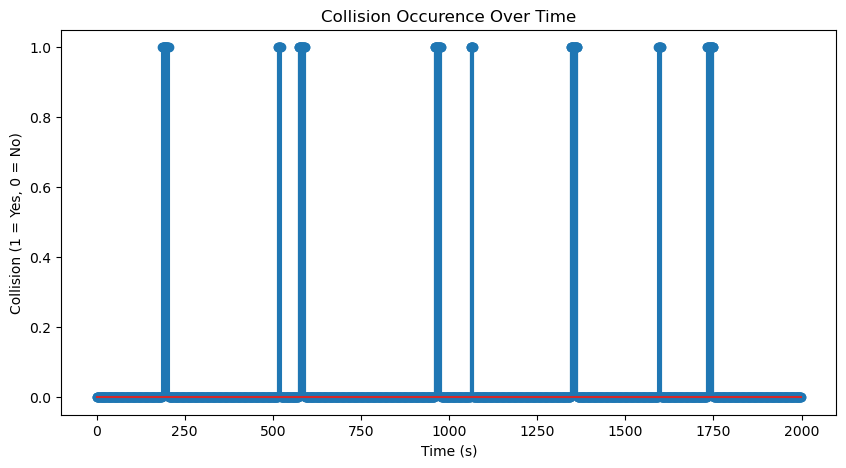

In [72]:
plt.figure(figsize=(10, 5))
plt.stem(video_features[np.random.randint(1, video_features.shape[0])])
plt.xlabel("Time (s)")
plt.ylabel("Collision (1 = Yes, 0 = No)")
plt.title("Collision Occurence Over Time")
plt.show()

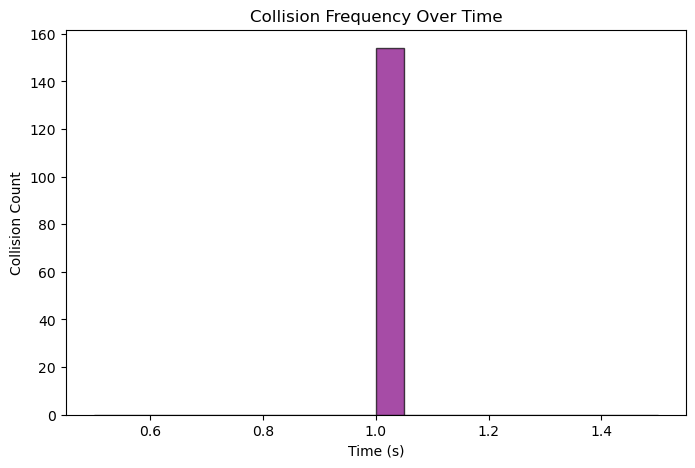

In [74]:
plt.figure(figsize=(8, 5))
vector = video_features[np.random.randint(1, video_features.shape[0])]
# Plot where it is equal to 1
plt.hist(vector[vector==1], bins=20, color="purple", alpha=0.7, edgecolor="black")
plt.xlabel("Time (s)")
plt.ylabel("Collision Count")
plt.title("Collision Frequency Over Time")
plt.show()


In [46]:
def extract_audio_features(audio_path, num=2000, time_duration=20):
    y, sr = librosa.load(audio_path, sr=None)

    # Computing energy function:
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)

    # Detecting peaks:
    peaks, _ = find_peaks(onset_env, height=0.2)

    # Computing peak width:
    widths, _, left_ips, right_ips = peak_widths(onset_env, peaks, rel_height=0.5)

    # Now, creating similar binary uniform vector:
    uniform_vector = np.zeros(num)

    for i in range(len(peaks)):
        start = (left_ips[i])
        end = (right_ips[i])
        start_frame = librosa.frames_to_time(start, sr=sr)
        end_frame = librosa.frames_to_time(end, sr=sr)
        
        # Now, we will fill the uniform vector with 1s where peaks occured:
        start_index = int((start_frame / time_duration) * num)
        end_index = int((end_frame / time_duration) * num)

        # Fixing Index out of bounds:
        start_index = max(0, start_index)
        end_index = min(num-1, end_index)

        uniform_vector[start_index:end_index+1] = 1

    return uniform_vector

In [59]:
# Now, iterating through all audio files and extracting features and storing it in a numpy array:
audio_features = np.zeros((45, 2000), dtype=int)

audio_dir = r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only"

for i in range(1, 46):
    audio_path = os.path.join(audio_dir, f"audio_only_ID_{i}.wav")
    features = extract_audio_features(audio_path)
    audio_features[i-1] = features

In [60]:
# Ensuring that all audio files got processed and have 2000 frames:
assert len(audio_features) == 45

for i in range(len(audio_features)):
    if len(audio_features[i]) != 2000:
        print(f"Audio {i} has {len(audio_features[i])} frames")

In [61]:
# Great, now we can save the features in a numpy file for future needs:

np.save("audio_features.npy", audio_features)

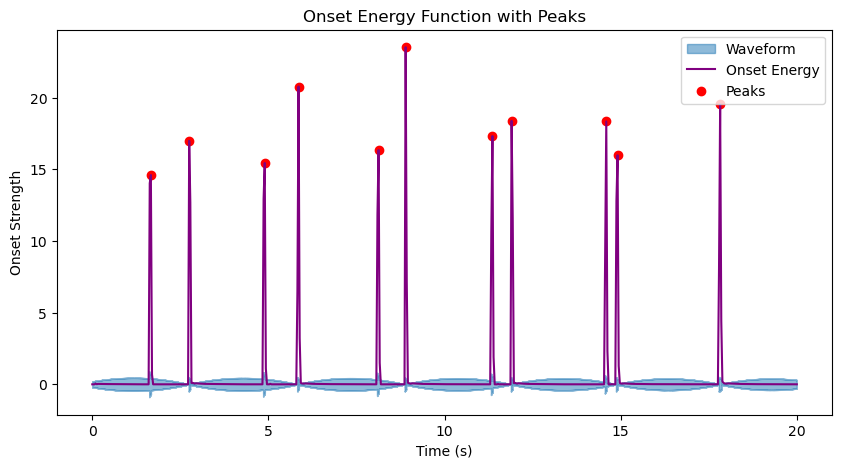

In [75]:
audio_rand = np.random.randint(1, audio_features.shape[0])
audio_hehehe = os.path.join(audio_dir, f"audio_only_ID_{audio_rand}.wav")
y, sr = librosa.load(audio_hehehe, sr=None)

# Compute onset energy
onset_env = librosa.onset.onset_strength(y=y, sr=sr)

# Detect peaks
peaks, _ = find_peaks(onset_env, height=0.2)

# Plot onset energy function
plt.figure(figsize=(10, 5))
librosa.display.waveshow(y, sr=sr, alpha=0.5, label="Waveform")
plt.plot(librosa.frames_to_time(np.arange(len(onset_env)), sr=sr), onset_env, label="Onset Energy", color='purple')
plt.scatter(librosa.frames_to_time(peaks, sr=sr), onset_env[peaks], color='red', label="Peaks", marker="o")

plt.xlabel("Time (s)")
plt.ylabel("Onset Strength")
plt.title("Onset Energy Function with Peaks")
plt.legend()
plt.show()

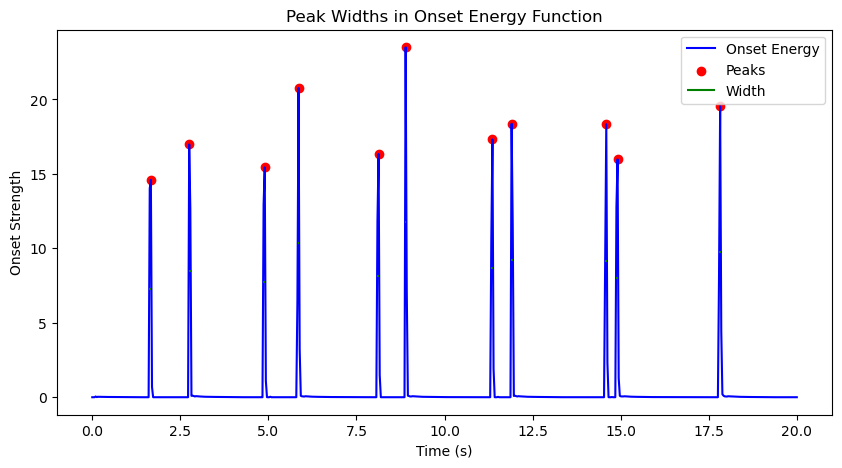

In [76]:
widths, _, left_ips, right_ips = peak_widths(onset_env, peaks, rel_height=0.5)

# Convert to time scale
left_times = librosa.frames_to_time(left_ips, sr=sr)
right_times = librosa.frames_to_time(right_ips, sr=sr)
peak_times = librosa.frames_to_time(peaks, sr=sr)

# Plot onset energy function
plt.figure(figsize=(10, 5))
plt.plot(librosa.frames_to_time(np.arange(len(onset_env)), sr=sr), onset_env, label="Onset Energy", color="blue")
plt.scatter(peak_times, onset_env[peaks], color="red", label="Peaks", marker="o")

# Draw peak widths
for i in range(len(peaks)):
    plt.hlines(y=onset_env[peaks[i]] * 0.5, xmin=left_times[i], xmax=right_times[i], color="green", label="Width" if i == 0 else "")

plt.xlabel("Time (s)")
plt.ylabel("Onset Strength")
plt.title("Peak Widths in Onset Energy Function")
plt.legend()
plt.show()

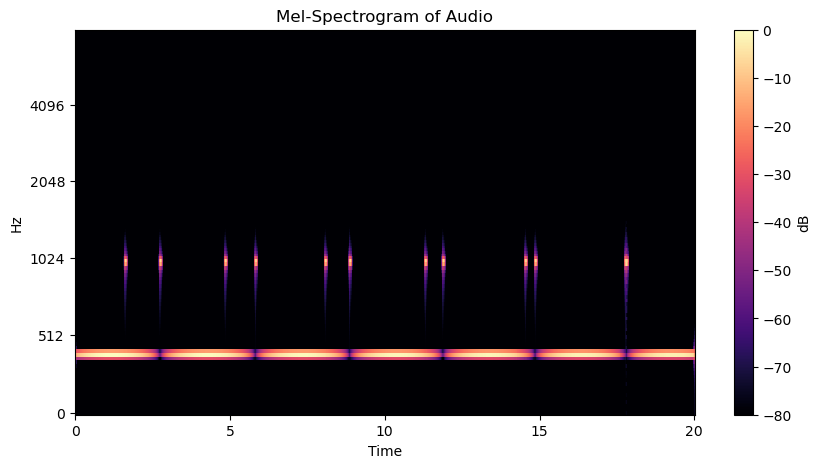

In [77]:
plt.figure(figsize=(10, 5))
librosa.display.specshow(librosa.amplitude_to_db(librosa.feature.melspectrogram(y=y, sr=sr), ref=np.max),
                         x_axis="time", y_axis="mel", sr=sr, cmap="magma")
plt.colorbar(label="dB")
plt.title("Mel-Spectrogram of Audio")
plt.show()

# **Binary Vector Matching: Methods & Best Approach**

## **Introduction**
When working with **binary vectors**, selecting an appropriate similarity measure is crucial for ensuring optimal **one-to-one pairing**. This document explores several techniques and identifies the best method for accurate and efficient matching.

---

## **1. Matching Techniques**

### **1.1 Cosine Similarity**
**Formula:**
```
cos(θ) = (A ⋅ B) / (||A|| ||B||)
```
**Pros:**
- Measures angular similarity between two vectors.
- Ignores magnitude differences.

**Cons:**
- Doesn't ensure unique one-to-one matching.
- Can result in multiple similar scores for different matches.

---

### **1.2 Jaccard Similarity**
**Formula:**
```
J(A, B) = |A ∩ B| / |A ∪ B|
```
**Pros:**
- Ideal for comparing binary (sparse) vectors.
- Measures **overlap** rather than magnitude or direction.

**Cons:**
- Doesn't guarantee unique one-to-one pairing.
- Not ideal for dense binary vectors.

---

### **1.3 Hamming Distance**
**Formula:**
```
H(A, B) = Σ (A_i ≠ B_i)
```
**Pros:**
- Counts exact mismatches, ensuring strict difference measurement.
- Works well for **binary string comparison**.

**Cons:**
- Doesn't consider partial similarity.
- Needs additional logic for one-to-one assignment.

---

### **1.4 Hungarian Algorithm (Kuhn-Munkres)**
**Concept:**
- Uses a **cost matrix** to find an **optimal one-to-one mapping**.
- The cost can be defined using **negative cosine similarity, Jaccard distance, or Hamming distance**.

**Steps:**
1. Compute a **pairwise distance matrix** using one of the similarity measures.
2. Apply the **Hungarian Algorithm** to minimize the total cost.
3. Obtain an **optimal one-to-one assignment** between vectors.

**Python Example:**
```python
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np

# Example binary vectors
A = np.array([[1, 0, 1], [0, 1, 1], [1, 1, 0]])
B = np.array([[1, 1, 0], [0, 1, 1], [1, 0, 1]])

# Compute distance matrix (e.g., Hamming distance)
cost_matrix = cdist(A, B, metric='hamming')

# Solve the assignment problem
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# Output optimal matches
matches = list(zip(row_ind, col_ind))
print("Optimal Matches:", matches)
```

**Pros:**
- Guarantees **one-to-one pairing**.
- Works with different similarity metrics (Hamming, Cosine, etc.).
- Optimizes overall assignments instead of individual scores.

**Cons:**
- Requires a known **set of vectors** to match against.
- Computationally expensive for large datasets.

---

## **2. Best Approach**
✅ **Hungarian Algorithm + Jaccard Distance** → Ensures strict **one-to-one matching** and works best for binary vectors.  
✅ **Hungarian Algorithm + Negative Cosine Similarity** → Best when weighted matching is needed.

### **Reasoning:**
- The **Hungarian Algorithm** enforces **unique pair assignments**, avoiding multiple similar matches.
- **Hamming Distance** is computationally simple and effective for binary vectors.
- If the vectors vary in magnitude but follow similar patterns, **Cosine Similarity** can be used with Hungarian Algorithm.

---

## **3. Conclusion**
For **binary vector matching**, the **Hungarian Algorithm with Jaccard Distance** is the best approach because it ensures an **optimal one-to-one pairing**, avoiding ambiguities caused by other similarity measures. For cases where weighted similarity is needed, **Negative Cosine Similarity** can be used instead.

🚀 **This ensures accurate and efficient matching in applications like NLP, clustering, and object tracking.**


In [63]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import jaccard_score

# Computing the similarity matrix:

similarity_matrix = np.zeros((video_features.shape[0], audio_features.shape[0]))
for i in range(video_features.shape[0]):
    for j in range(audio_features.shape[0]):
        similarity_matrix[i, j] = jaccard_score(video_features[i], audio_features[j])

# Now, we will solve the assignment problem using Hungarian Algorithm:
row_ind, col_ind = linear_sum_assignment(-similarity_matrix)

# Save the matching in the format AUDIO, VIDEO:
matching = [(i+1, j+1) for i, j in zip(col_ind, row_ind)]

# Write name of the audio and video files as audio_only_ID_{audio_id}.wav and video_only_ID_{video_id}.mp4
matching = [(f"audio_only_ID_{audio_id}.wav", f"video_only_ID_{video_id}.mp4") for audio_id, video_id in matching]

# Now, convert it in dataframe with AUDIO, VIDEO columns and save it in a .csv format:
df = pd.DataFrame(matching, columns=["AUDIO", "VIDEO"])

df.to_csv("OPTIMAL_MATCHING.csv", index=False)

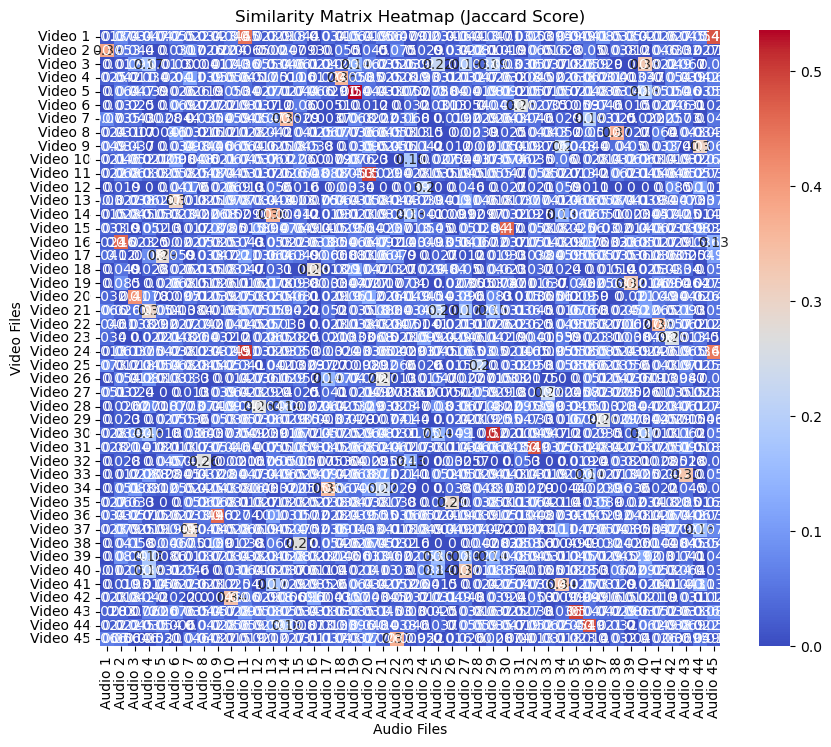

In [80]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap="coolwarm", annot=True, xticklabels=[f"Audio {i+1}" for i in range(audio_features.shape[0])], 
            yticklabels=[f"Video {i+1}" for i in range(video_features.shape[0])])
plt.xlabel("Audio Files")
plt.ylabel("Video Files")
plt.title("Similarity Matrix Heatmap (Jaccard Score)")
plt.show()

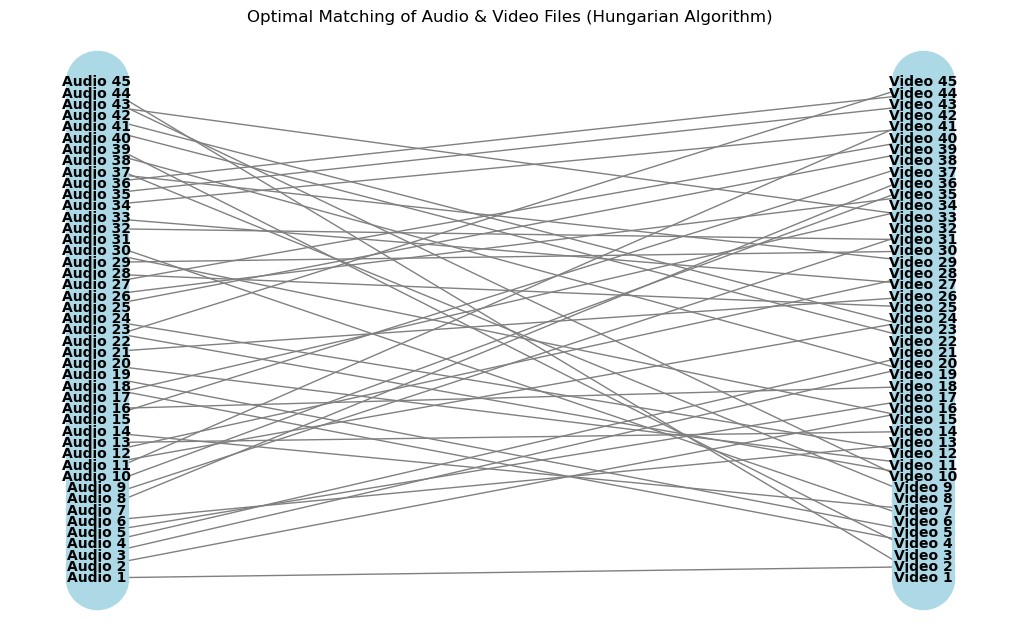

In [ ]:
# Visualizing something new:
import networkx as nx

G = nx.Graph()

audio_nodes = [f"Audio {i+1}" for i in range(audio_features.shape[0])]
video_nodes = [f"Video {i+1}" for i in range(video_features.shape[0])]

G.add_nodes_from(audio_nodes, bipartite=0)  # Left side (Audio)
G.add_nodes_from(video_nodes, bipartite=1)  # Right side (Video)

# Add edges for optimal matching
edges = [(f"Audio {col+1}", f"Video {row+1}") for row, col in zip(row_ind, col_ind)]
G.add_edges_from(edges)

# Draw the bipartite graph
plt.figure(figsize=(10, 6))
pos = nx.bipartite_layout(G, audio_nodes)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=2000, font_size=10, font_weight="bold")
plt.title("Optimal Matching of Audio & Video Files (Hungarian Algorithm)")
plt.show()

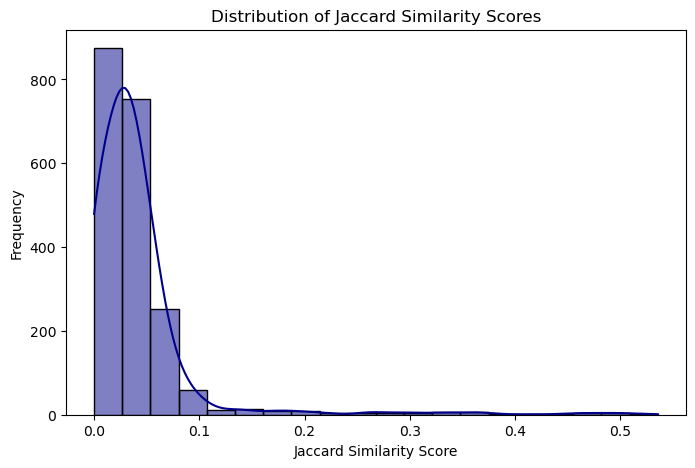

In [82]:
plt.figure(figsize=(8, 5))
sns.histplot(similarity_matrix.flatten(), bins=20, kde=True, color="darkblue")
plt.xlabel("Jaccard Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Jaccard Similarity Scores")
plt.show()


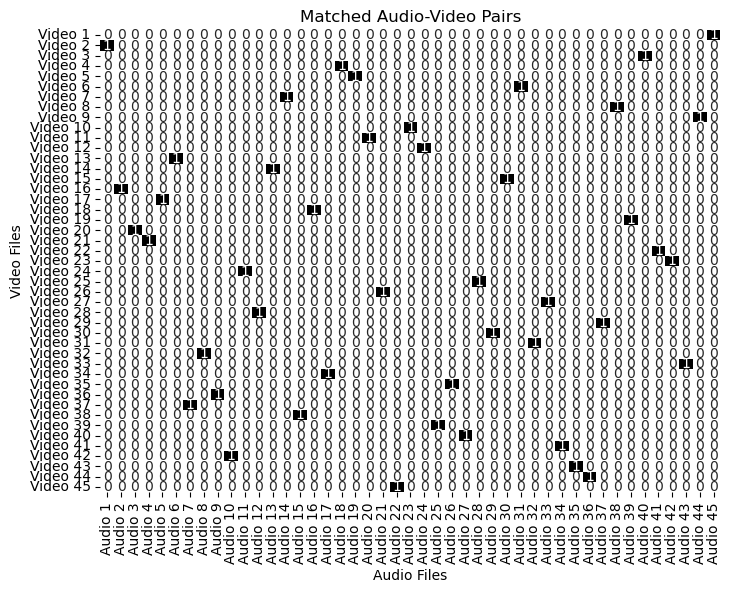

In [83]:
match_matrix = np.zeros_like(similarity_matrix)
match_matrix[row_ind, col_ind] = 1  # Assign matched pairs as 1

plt.figure(figsize=(8, 6))
sns.heatmap(match_matrix, cmap="binary", annot=True, cbar=False, xticklabels=[f"Audio {i+1}" for i in range(audio_features.shape[0])], 
            yticklabels=[f"Video {i+1}" for i in range(video_features.shape[0])])
plt.xlabel("Audio Files")
plt.ylabel("Video Files")
plt.title("Matched Audio-Video Pairs")
plt.show()


In [64]:
print(f"Total unique audio files: {len(df["AUDIO"].unique())}")
print(f"Total unique video files: {len(df["VIDEO"].unique())}")

Total unique audio files: 45
Total unique video files: 45


In [65]:
# GOOD, so all files have been matched.
# Now, combining them, to see the final output:
def merge_video_audio(video_path, audio_path, output_path):
    """
    Merges the given video with the best-matching audio.
    """
    input_video = ffmpeg.input(video_path)
    input_audio = ffmpeg.input(audio_path)
    
    (
        ffmpeg
        .output(input_video, input_audio, output_path, vcodec="copy", acodec="aac", strict="experimental")
        .run(overwrite_output=True)
    )

In [67]:
video_dir = r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only"
audio_dir = r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only"

# Match using the df we got
data = pd.read_csv("OPTIMAL_MATCHING.csv")

In [69]:
os.makedirs("merged_videos", exist_ok=True)
for index, row in df.iterrows():
    audio_file = os.path.join(audio_dir, row["AUDIO"])
    video_file = os.path.join(video_dir, row["VIDEO"])

    output_file = os.path.join("merged_videos", f"video_{index+1}.mp4")

    print(f"Merging: {video_file} + {audio_file} => {output_file}")

    merge_video_audio(video_file, audio_file, output_file)

print(f"All files have been merged and saved in output directory.")


Merging: C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only\video_only_ID_1.mp4 + C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_45.wav => merged_videos\video_1.mp4
Merging: C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only\video_only_ID_2.mp4 + C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_1.wav => merged_videos\video_2.mp4
Merging: C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only\video_only_ID_3.mp4 + C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_40.wav => merged_videos\video_3.mp4
Merging: C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only\video_only_ID_4.mp4 + C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_18.wav => merged_videos\video_4.mp4
Merging: C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only\video_only_ID_5.mp4 + C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_19.wav => me